<a href="https://colab.research.google.com/github/vansh-virmani/NextGenAI/blob/main/LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding,LSTM,Dense
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [ ]:
reviews=[
    'i like the movie',
    'the film was amazing',
    'i hate the movie',
    'the file is terrible',
    'i really enjoyed the movie',

    "I’m really disappointed with the movie; it broke after one use.",
    'the movie was boring'



]
labels=[1,1,0,0,1,0,0]

In [ ]:
tokenizer=Tokenizer()
tokenizer.fit_on_texts(reviews)
sequences=tokenizer.texts_to_sequences(reviews)


In [ ]:
print("Sequences:", sequences)


Sequences: [[3, 6, 1, 2], [1, 7, 4, 8], [3, 9, 1, 2], [1, 10, 11, 12], [3, 5, 13, 1, 2], [14, 5, 15, 16, 1, 2, 17, 18, 19, 20, 21], [1, 2, 4, 22]]


In [ ]:
X=pad_sequences(sequences)
y=np.array(labels)

In [ ]:
vocab_size= len(tokenizer.word_index)+1
max_len=X.shape[1]

In [ ]:
model=Sequential([
    Embedding(input_dim=vocab_size,output_dim=10,input_length=max_len),
    LSTM(units=32),
    Dense(units=1,activation='sigmoid')]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
model.compile(loss='binary_crossentropy', optimizer='adam')

In [ ]:
model.fit(X,y,epochs=50)

Epoch 1/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.6936
Epoch 2/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.6928
Epoch 3/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.6921
Epoch 4/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.6914
Epoch 5/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.6906
Epoch 6/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 0.6899
Epoch 7/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 0.6892
Epoch 8/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.6884
Epoch 9/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.6876
Epoch 10/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 0.6868
Epoch 11/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 0.6860
Epoch 12/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.6851
Epoch 13/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.6842
Epoch 14/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.6833
Epoch 15/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 0.6823
Epoch 16/50
1/1 ━━━━━━━━━━━━━━━━━━━━

In [ ]:
test_review = 'this movie was fantastic and amazing'

In [ ]:
# Tokenize and pad the new review
new_sequences = tokenizer.texts_to_sequences([test_review])
padded_new_sequences = pad_sequences(new_sequences, maxlen=max_len)

In [ ]:
# Make a prediction
prediction = model.predict(padded_new_sequences)

# Print the prediction
print(f"Review: '{test_review}'")
print(f"Prediction score: {prediction[0][0]:.4f}")

# Interpret the prediction
if prediction[0][0] > 0.5:
    print("Sentiment: Positive")
else:
    print("Sentiment: Negative")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step
Review: 'this movie was fantastic and amazing'
Prediction score: 0.4236
Sentiment: Negative


### Extract Background from Face Detection ROI

First, we need to download the Haar Cascade XML file for face detection. This classifier is used by OpenCV to identify faces in an image.

In [1]:
# Download Haar Cascade classifier for face detection
!wget -nc https://raw.githubusercontent.com/opencv/opencv/4.x/data/haarcascades/haarcascade_frontalface_default.xml
print("Downloaded 'haarcascade_frontalface_default.xml'")

--2026-04-29 09:11:32--  https://raw.githubusercontent.com/opencv/opencv/4.x/data/haarcascades/haarcascade_frontalface_default.xml
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 930127 (908K) [text/plain]
Saving to: ‘haarcascade_frontalface_default.xml’

haarcascade_frontal 100%[===================>] 908.33K  --.-KB/s    in 0.05s   

2026-04-29 09:11:32 (18.9 MB/s) - ‘haarcascade_frontalface_default.xml’ saved [930127/930127]

Downloaded 'haarcascade_frontalface_default.xml'


Now, let's write the code to load an image, detect faces, and then create a new image where the faces are masked out (e.g., filled with black) to effectively 'extract the background'.

Found 1 face(s)!


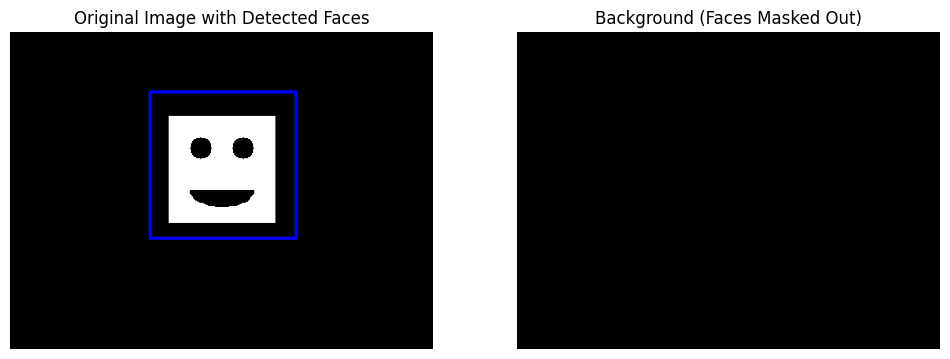

In [2]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Load the pre-trained face cascade classifier
face_cascade = cv2.CascadeClassifier('haarcascade_frontalface_default.xml')

# --- Example Image (You can upload your own or use a sample) ---
# For demonstration, let's create a dummy image with a face-like structure
# In a real scenario, you would load an actual image:
# img = cv2.imread('path/to/your/image.jpg')
# if img is None:
#     print("Error: Could not load image. Please check the path.")
#     exit()

# Create a dummy image for demonstration
img = np.zeros((300, 400, 3), dtype=np.uint8) # Black image
# Add a 'face' (e.g., a white rectangle)
cv2.rectangle(img, (150, 80), (250, 180), (255, 255, 255), -1) # White rectangle as face
cv2.circle(img, (180, 110), 10, (0, 0, 0), -1) # Left eye
cv2.circle(img, (220, 110), 10, (0, 0, 0), -1) # Right eye
cv2.ellipse(img, (200, 150), (30, 15), 0, 0, 180, (0, 0, 0), -1) # Mouth

# Convert the image to grayscale (face detection works better on grayscale)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Detect faces in the image
# The detectMultiScale function detects objects of different sizes in the input image.
# The detected objects are returned as a list of rectangles.
faces = face_cascade.detectMultiScale(
    gray,
    scaleFactor=1.1,
    minNeighbors=5,
    minSize=(30, 30),
    flags=cv2.CASCADE_SCALE_IMAGE
)

# Create a copy of the original image to draw on and for background extraction
img_with_faces_masked = img.copy()

# If faces are detected, process them
if len(faces) > 0:
    print(f"Found {len(faces)} face(s)!")
    for (x, y, w, h) in faces:
        # Draw a rectangle around the detected face on the original image (optional for visualization)
        cv2.rectangle(img, (x, y), (x+w, y+h), (255, 0, 0), 2)

        # Mask out the face region from the copy to get the 'background'
        # Fill the face region with black (0,0,0) - this extracts the background by removing the face
        cv2.rectangle(img_with_faces_masked, (x, y), (x+w, y+h), (0, 0, 0), -1) # -1 for filled rectangle

        # Alternatively, to blur the face:
        # face_roi = img_with_faces_masked[y:y+h, x:x+w]
        # face_roi = cv2.GaussianBlur(face_roi, (99, 99), 30)
        # img_with_faces_masked[y:y+h, x:x+w] = face_roi

    # Display the original image with detected faces and the background extracted image
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title('Original Image with Detected Faces')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(cv2.cvtColor(img_with_faces_masked, cv2.COLOR_BGR2RGB))
    plt.title('Background (Faces Masked Out)')
    plt.axis('off')
    plt.show()
else:
    print("No faces detected.")
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title('Original Image (No Faces Detected)')
    plt.axis('off')
    plt.show()

**Explanation:**

1.  **Download Classifier:** We first download `haarcascade_frontalface_default.xml`, which contains the pre-trained data for face detection.
2.  **Load Image and Classifier:** The code loads an image (using a dummy image for demonstration) and the Haar Cascade classifier.
3.  **Grayscale Conversion:** Images are converted to grayscale because Haar Cascades typically work on intensity values, not colors.
4.  **Face Detection:** `face_cascade.detectMultiScale()` is the core function for detecting faces. It returns a list of rectangles, each representing a detected face. The parameters control the detection sensitivity.
5.  **Background Extraction (Masking):**
    *   A copy of the original image (`img_with_faces_masked`) is made.
    *   For each detected face, a filled black rectangle is drawn over the face region in this copied image. This effectively removes the face, leaving only the surrounding 'background'.
    *   You could uncomment the alternative section to blur the faces instead of filling them with black, which is another common way to handle faces when focusing on the background or anonymization.
6.  **Display Results:** The original image with face bounding boxes and the image with masked faces (the extracted background) are displayed for comparison.